# FIM × ftnode-structure — diagnostics

**Question (the gate).** Does the ftnode structural prior $F(x,u)=A(x)\,(x-g(x,u))$ (with $A$
negative definite *by construction*) **mesh with a pretrained ODE foundation model** (FIM-ODE,
[arXiv:2602.08733](https://arxiv.org/abs/2602.08733)), so that the structure can become the backbone of
our own foundation model? Target: the Duffing oscillator. The gate is *not* "does FIM beat a cold start".

Two experiments, read together:

| | Experiment 1 — heavy factorial (5 cells) | Experiment 2 — quick retune |
|---|---|---|
| FIM's role | **is** the RK4 drift; backprop-through-time through it | **target / feature**, distilled by regression |
| metric | $q$-rollout held-out test MSE, $L=600$, **plus the rollout metric set** | pointwise drift MSE vs the true field $f^*$ |
| structure fit by | 200-step rollout loss | pointwise regression onto $f_{\text{FIM}}$ |
| cost / scope | ~0.5–1 day/seed on GPU, 3 seeds | ~1 min on CPU, 1 seed |
| evidence | `runs/fim_factorial/score_eval_5cell.json` | `runs/fim_quick/report.json` |

Both share the identical structural construction and the identical
$\operatorname{sym}A\preceq-\sigma_{\min}I$ guarantee. A short **saturation** note fixes the bar the FIM
arm must beat.

**Hardware.** Heavy factorial: **NVIDIA Quadro RTX 6000 (24 GB)**, two of them, one FIM cell + seed per
GPU. Quick retune: **CPU only** — AMD Ryzen Threadripper 3960X (24C/48T) — deliberately, so it never
contends with a live GPU run.

## Why this line of work — FIM-ODE's own stated limits

FIM-ODE ([arXiv:2602.08733](https://arxiv.org/abs/2602.08733)) is a pretrained neural operator:
from a short context of a system's trajectories it infers that system's vector field
$\hat f_\phi(x\mid D)$ in **one forward pass**, no per-system optimisation. Two limitations the
authors state are exactly what motivate pairing it with the ftnode structure:

1. **No stability guarantee — the field is unconstrained.** The decoder is a free neural field
   with *no mechanism to preserve qualitative structure*. The authors show this directly: on the
   frictionless pendulum the true marginal **centre** is turned into a **weak unstable spiral** by
   FIM. A pretrained free field can invent instability where the truth has none.
2. **The prior is nonstationary and blows up — hence $d\le 3$.** Each field component is a sparse
   polynomial of **total degree $\le 3$** with $\mathrm{Var}(f_i(x))\sim\|x\|^{2\alpha}$, so
   $\|f\|$ grows with $\|x\|$ and sampled systems diverge in finite time. The difficulty of
   *generating* a non-exploding prior worsens with dimension, which is why the released model is
   capped at state dimension $d\in\{1,2,3\}$.

The ftnode structure supplies exactly what (1) lacks: $F(x,u)=A(x)\,(x-g(x,u))$ with
$\operatorname{sym}A\preceq-\sigma_{\min}I$ makes a ball forward-invariant and equilibria stable
**by construction** — a centre cannot silently become an unstable spiral. So these experiments ask
a two-directional question: **can the ftnode structure supply FIM's missing stability, and can a
pretrained FIM field warm-start (or be carried by) the structure?**

Duffing ($\ddot q+\delta\dot q+q^3-q=u$) is chosen deliberately: it is **degree-3 and dissipative**,
so it sits *inside* FIM's prior degree. A failure is then about *structure and optimisation*, not a
prior-degree mismatch — while the cubic $-q^3$ term still stress-tests the bounded structure's
far-field (Experiment 2).

## The plant and the shared observation model

State $x=(q,\dot q)\in\mathbb R^2$. Duffing ODE

$$\ddot q + \delta\dot q + q^3 - q = u,\qquad \delta=0.2,\quad u\ \text{constant per trajectory},$$

as a first-order field ( `ftnode.systems.duffing_field_torch` ):

$$f^*(x,u)=\begin{bmatrix}\dot q\\[2pt]-\delta\dot q - q^3 + q + u\end{bmatrix}.$$

The **measured output is $y=q=x_0$ only**; $\dot q$ is never observed. Every cell of every
experiment shares one parameter-free initial-state estimate from the $q$-window
(`estimate_x0`): $\dot q_0=(q_{-1}-q_{-2})/h,\ q_0=q_{-1}+h\dot q_0$, and one integrator,
classical RK4 with $h=0.05$. So cells differ **only** in the field $F(x,u)$ — never in the
data, the readout, or the initial state.

In [3]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = 'serif'

ROOT = pathlib.Path.cwd()
fac = json.load(open(ROOT / "runs/fim_factorial/score_eval_5cell.json"))   # cells 1-5, full metric set
quick = json.load(open(ROOT / "runs/fim_quick/report.json"))

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "font.size": 10, "axes.axisbelow": True})
# colourblind-safe (Okabe-Ito): structure axis (free vs bounded), backbone axis (cold vs FIM)
C_FREE, C_STRUCT = "#E69F00", "#0072B2"   # orange = free, blue = A(x-g)
C_COLD, C_FIM    = "#999999", "#009E73"   # grey = cold, green = FIM

# One fixed identity per factorial cell (validated: CVD ΔE >= 9.6 between neighbours).
# Light = cold, dark = FIM; orange family = free, blue = A(x-g), purple = the matched FIM MLP head.
CELLS = ["cold-unstructured", "cold-structured", "fim-unstructured", "fim-structured", "fim-mlp-head"]
CELL_LABEL = {"cold-unstructured": "1 cold · free", "cold-structured": "2 cold · A(x-g)",
              "fim-unstructured": "3 FIM · pass-through", "fim-structured": "4 FIM · A(x-g)",
              "fim-mlp-head": "5 FIM · MLP head"}
CELL_COLOR = {"cold-unstructured": "#E69F00", "cold-structured": "#56B4E9",
              "fim-unstructured": "#D55E00", "fim-structured": "#0072B2", "fim-mlp-head": "#CC79A7"}
CELL_MARK = {"cold-unstructured": "o", "cold-structured": "s", "fim-unstructured": "^",
             "fim-structured": "D", "fim-mlp-head": "v"}
SEED_KEYS = ["0", "1", "2"]
M = fac["metrics"]                                       # M[cell][seed][metric]

def per_seed(cell, key):
    return np.array([M[cell][s][key] for s in SEED_KEYS], float)

hist = {c: [json.load(open(ROOT / f"runs/fim_factorial/{c}/seed{s}.hist.json")) for s in SEED_KEYS]
        for c in CELLS}
print("factorial cells:", list(fac["scores"]))
print("quick stages   :", [k for k in quick if k.startswith("cell")])

factorial cells: ['cold-unstructured', 'cold-structured', 'fim-unstructured', 'fim-mlp-head', 'fim-structured']
quick stages   : ['cell3_zero_shot', 'cell3_retuned', 'cell4_distilled', 'cell4_finetuned']


## Experiment 1 — the heavy factorial (cells 1–5)

Trained by `ftnode/physical/train.py`: estimate $x_0$, integrate $x_{k+1}=\mathrm{RK4}(F,x_k,u,h)$
for $L=200$ steps, read $\hat q_k=x_k[0]$, minimise the **measured-$q$** loss

$$\mathcal L_\theta=\tfrac1{L+1}\textstyle\sum_k(\hat q_k-y_k)^2$$

(no $\dot q$ target, no residual regulariser: $\lambda_{\text{res}}=0$ everywhere).
Adam, cosine LR, grad-clip 1.0, eval at $L_{\text{eval}}=600$, early-stop patience 50, cap 600.
The two factors:

**① Backbone — cold vs pretrained FIM.** The pretrained FIM-ODE is a neural operator
$\hat f_\phi(x\mid D):\mathbb R^2\times\text{context}\to\mathbb R^2$ (13M params). Here it is
placed **inside the RK4 integrator as the drift** (`ftnode/fim/backbone.py`):

- `prepare(W,h)` reconstructs a 2-D context ($\dot q$ = central diff of the $q$-window) and
  encodes it **once per minibatch** → keys/values $D$ and norm stats $\mu_Y,\sigma_Y,\gamma$;
  $u$ enters implicitly through this context.
- `drift(x)` at **each RK4 stage**: pad $x\in\mathbb R^2\to\mathbb R^{M}$ (grad-keeping `cat`),
  normalise $x_{\text n}=(x-\mu_Y)/\sigma_Y$, decode
  $\text{drift}_{\text n}=\text{FIM.function\_decoding}(x_{\text n},D)$ (8 cross-attn blocks +
  MLP, **gradient-checkpointed**), renormalise $\text{drift}=\sigma_Y\,\text{drift}_{\text n}$.

One FIM forward per stage → $4$/step → $512\times200\times4\approx4.1\times10^5$ passes/epoch,
full backprop-through-time.

**② Structure — free vs bounded.** With $A=-(\sigma_{\min}I+P)+K$, $P=LL^\top\succeq0$,
$K^\top=-K$, both spectrally clamped ⇒ $\operatorname{sym}A\preceq-\sigma_{\min}I$ everywhere,
$\kappa(A)\le(\sigma_{\min}+c_P+c_K)/\sigma_{\min}$ ($\sigma_{\min}=0.1$, $\kappa_{\max}=25$,
skew-frac 0.6); $g=R_g\tanh(\cdot)\in[-R_g,R_g]^2$, $R_g=2$.

| cell | backbone | structure | $F(x,u)$ |
|---|---|---|---|
| 1 | cold | free | $\mathrm{MLP}([x,u])$ |
| 2 | cold | bounded | $A(x)\,(x-g(x,u))$ |
| 3 | FIM | free, pass-through | $\text{drift}_{\text{FIM}}(x)+\text{res}([\text{drift}_{\text{FIM}}(x),x])$, res last-layer $=0$ (warm start); **no direct $u$** |
| 4 | FIM | bounded | $A(\text{feat})\,(x-g(\text{feat},u))$, $\text{feat}=[\text{drift}_{\text{FIM}}(x),x]$ |
| 5 | FIM | free, matched | $\mathrm{MLP}([\text{drift}_{\text{FIM}}(x),x,u])$, default init, **no pass-through** |

In cell 4 the FIM drift is a **feature** into the neg-def heads, so
$\operatorname{sym}A\preceq-\sigma_{\min}I$ holds whatever FIM emits. The cell-3 residual and the cell-5
head are both width-matched to the cell-4 head parameter count (26,670 vs 26,634 for cell 5).

**Why cell 5.** Cell 3 differs from cell 4 in *two* ways besides the structure: it passes the FIM drift
through, and its field never reads $u$ directly. Cell 5 reads exactly the cell-4 head inputs with no
pass-through, so **$c_4-c_5$ isolates the structure** on a FIM field. $c_3-c_5$ measures the cell-3
design (it cannot separate the pass-through from the missing $u$).

**Score** (`scripts/score_fim_factorial.py`): rebuild each (cell,seed), roll out $L=600$ on fresh test
seeds 1000–1004 (320 trajectories), mean $(\hat q-y)^2$, plus the rollout metric set below. Contrasts,
paired over the 3 model seeds: $\text{struct}_\text{cold}=c_2-c_1$, $\text{struct}_\text{FIM}=c_4-c_3$,
$\text{pretrain}=c_3-c_1$, $\text{interaction}=(c_4-c_3)-(c_2-c_1)$, and the matched set
$\text{struct}_\text{FIM,matched}=c_4-c_5$, $\text{interaction}_\text{matched}=(c_4-c_5)-(c_2-c_1)$,
$\text{pass-through}=c_3-c_5$.

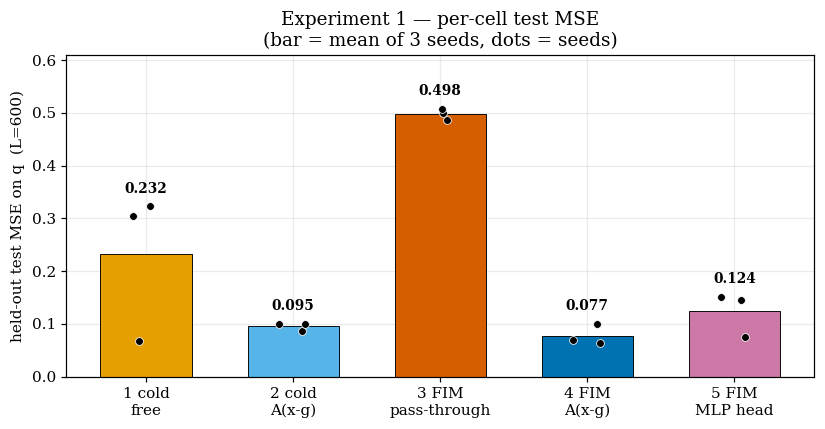

In [4]:
means = [np.mean(list(fac["scores"][k].values())) for k in CELLS]
seeds = [list(fac["scores"][k].values()) for k in CELLS]

fig, ax = plt.subplots(figsize=(7.6, 4.0))
x = np.arange(len(CELLS))
ax.bar(x, means, color=[CELL_COLOR[c] for c in CELLS], edgecolor="k", linewidth=0.6,
       width=0.62, zorder=2)
rng = np.random.default_rng(0)
for i, s in enumerate(seeds):
    jit = (rng.random(len(s)) - 0.5) * 0.20
    ax.scatter(x[i] + jit, s, color="k", s=26, zorder=4, edgecolor="w", linewidth=0.5)
ymax = max(max(s) for s in seeds)
for i, (m, s) in enumerate(zip(means, seeds)):
    ax.text(i, max(m, max(s)) + 0.02, f"{m:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_ylim(0, ymax * 1.20)
ax.set_xticks(x); ax.set_xticklabels([CELL_LABEL[c].replace(" · ", "\n") for c in CELLS])
ax.set_ylabel("held-out test MSE on q  (L=600)")
ax.set_title("Experiment 1 — per-cell test MSE\n(bar = mean of 3 seeds, dots = seeds)")
plt.tight_layout(); plt.show()

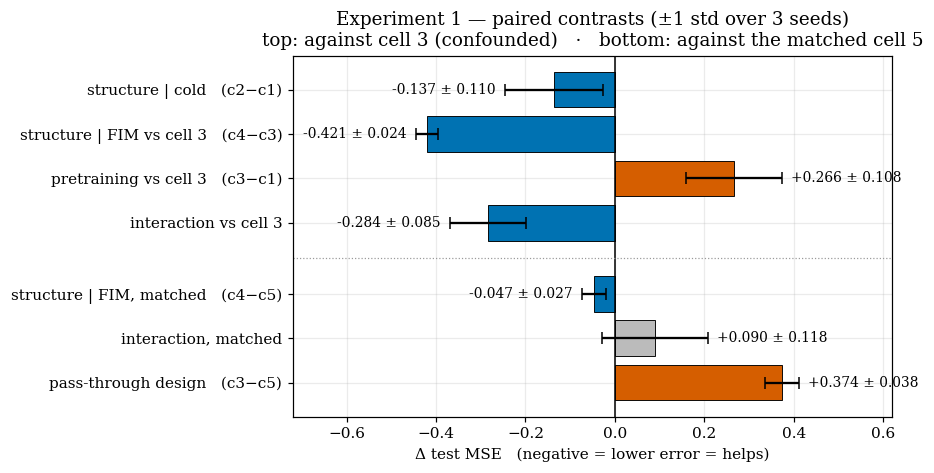

c4 − c5 per seed: [-0.011 -0.052 -0.078]


In [5]:
keys = ["structure_cold (cell2-cell1)", "structure_fim (cell4-cell3)",
        "pretraining (cell3-cell1)", "interaction ((cell4-cell3)-(cell2-cell1))",
        "structure_fim_matched (cell4-cell5)", "interaction_matched ((cell4-cell5)-(cell2-cell1))",
        "passthrough (cell3-cell5)"]
nice = ["structure | cold   (c2−c1)", "structure | FIM vs cell 3   (c4−c3)",
        "pretraining vs cell 3   (c3−c1)", "interaction vs cell 3",
        "structure | FIM, matched   (c4−c5)", "interaction, matched",
        "pass-through design   (c3−c5)"]
mu = np.array([fac["contrasts"][k]["mean"] for k in keys])
sd = np.array([fac["contrasts"][k]["std"] for k in keys])
# blue = lowers error (helps), red = raises error; grey = |mean| < 1 std (noise)
col = ["#BBBBBB" if abs(m) < s else (C_STRUCT if m < 0 else "#D55E00") for m, s in zip(mu, sd)]

fig, ax = plt.subplots(figsize=(8.4, 4.4))
y = np.arange(len(keys))[::-1].astype(float)
y[4:] -= 0.6                                            # gap between the original and matched sets
ax.barh(y, mu, xerr=sd, color=col, edgecolor="k", linewidth=0.6,
        error_kw=dict(ecolor="k", capsize=4), zorder=2)
ax.axvline(0, color="k", linewidth=1)
ax.axhline((y[3] + y[4]) / 2, color="0.6", lw=0.8, ls=":")
for yi, m, s in zip(y, mu, sd):
    ax.text(m - s - 0.02 if m < 0 else m + s + 0.02, yi, f"{m:+.3f} ± {s:.3f}",
            va="center", ha="right" if m < 0 else "left", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(nice)
ax.set_xlabel("Δ test MSE   (negative = lower error = helps)")
ax.set_title("Experiment 1 — paired contrasts (±1 std over 3 seeds)\n"
             "top: against cell 3 (confounded)   ·   bottom: against the matched cell 5")
ax.set_xlim(-0.72, 0.62)
plt.tight_layout(); plt.show()
print("c4 − c5 per seed:", np.round(np.array(list(fac["scores"]["fim-structured"].values()))
                                    - np.array(list(fac["scores"]["fim-mlp-head"].values())), 3))

### Experiment 1 — run time

FIM cells measured **≈184 s/epoch** (cells 3, 4) and **≈208 s/epoch** (cell 5) on one Quadro RTX 6000
(the cost is the $4.1\times10^5$ gradient-checkpointed FIM passes/epoch, not the optimiser). Early-stop
keeps the best epoch and runs 50 more (patience), so a run trains *stop epoch + 1* epochs and
wall-clock $\approx(\text{stop}+1)\times\text{s/epoch}$. Cold cells carry no 13M backbone — seconds per
epoch, not separately logged. The cell below reads the best and stop epochs from each run's
`hist.json` and turns the FIM rows into approximate GPU wall-clock.

cell                     seed 0: best/stop   seed 1: best/stop   seed 2: best/stop
1 cold · free                    66 / 116            298 / 348            183 / 233  
2 cold · A(x-g)                 164 / 214            196 / 246            220 / 270  
3 FIM · pass-through            127 / 177             33 / 83             154 / 204  
4 FIM · A(x-g)                  281 / 331            478 / 528            510 / 560  
5 FIM · MLP head                469 / 519            134 / 184             56 / 106  


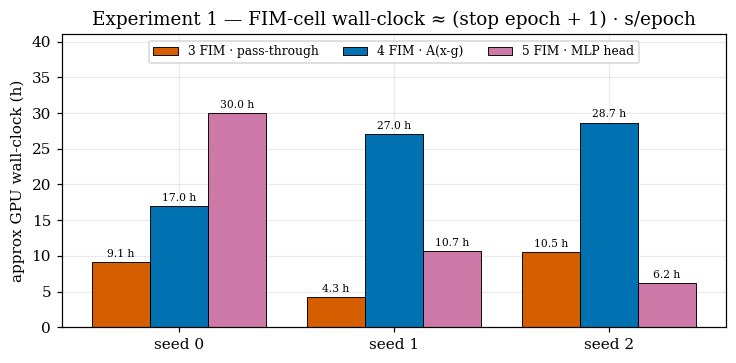

In [6]:
print(f"{'cell':22s}" + "".join(f"   seed {s}: best/stop" for s in SEED_KEYS))
for c in CELLS:
    print(f"{CELL_LABEL[c]:22s}" + "".join(f"   {h['best_epoch']:>10d} / {h['stopped_early_at']:<5d}"
                                            for h in hist[c]))

S_PER_EPOCH = {"fim-unstructured": 184.0, "fim-structured": 184.0, "fim-mlp-head": 208.0}
fig, ax = plt.subplots(figsize=(6.8, 3.4))
x = np.arange(3); w = 0.27
for j, c in enumerate(S_PER_EPOCH):
    hrs = [(h["stopped_early_at"] + 1) * S_PER_EPOCH[c] / 3600 for h in hist[c]]
    b = ax.bar(x + (j - 1) * w, hrs, w, label=CELL_LABEL[c], color=CELL_COLOR[c],
               edgecolor="k", linewidth=0.6)
    ax.bar_label(b, fmt="%.1f h", fontsize=7, padding=2)
ax.set_xticks(x); ax.set_xticklabels(["seed 0", "seed 1", "seed 2"])
ax.set_ylabel("approx GPU wall-clock (h)")
ax.set_title("Experiment 1 — FIM-cell wall-clock ≈ (stop epoch + 1) · s/epoch")
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)
ax.legend(fontsize=8, ncol=3, loc="upper center")
plt.tight_layout(); plt.show()

### Experiment 1 — score decomposition: the rollout metric set

The aggregate score weights all $601$ steps equally. Duffing ($\delta=0.2$) damps as about
$e^{-\delta t/2}$, so after step 200 ($t=10$) most trajectories sit near a well centre $q=\pm1$.
A cell can therefore score well by picking the right well, whatever it does in the transient —
or badly because a handful of trajectories settle in the wrong well. `ftnode/physical/metrics.py`
(`rollout_metrics`) splits the score. Symbols, over the 320 pooled test trajectories:

- $e_{a:b}$ — mean $(\hat q_k-q_k)^2$ over steps $a\le k<b$; windows $0{:}50$, $50{:}200$, $200{:}400$, $400{:}601$.
- **wrong well** — $\operatorname{sign}\bar{\hat q}_{400:601}\neq\operatorname{sign}\bar q_{400:601}$.
  A wrong-well trajectory costs $\approx(\pm1\mp1)^2=4$ per late step.
- **crosser** — a trajectory whose early sign ($\bar q_{0:20}$) differs from its final well (72 of 320).
  Picking the well on a crosser needs the dynamics, not the initial state.
- **wrong-well error share** — fraction of total squared error from wrong-well trajectories;
  **late MSE, correct wells** — $e_{400:601}$ on the trajectories that pick the right well.
- **transient MSE** — $e_{0:200}$ after removing each trajectory's own late offset (model and truth).
- **oscillation-energy ratio** — $\overline{\operatorname{var}}_{50:200}(\hat q)/\overline{\operatorname{var}}_{50:200}(q)$;
  1 = right amplitude, 0 = flat. **dominant-frequency match** — fraction of trajectories whose dominant
  FFT bin over steps $0{:}200$ matches the truth (a flat or non-finite prediction never matches).

Two **oracle** baselines use each true trajectory's future and carry no dynamics: its final-well centre
$\pm1$, and its own time-mean. The cells see only the 8-sample window.

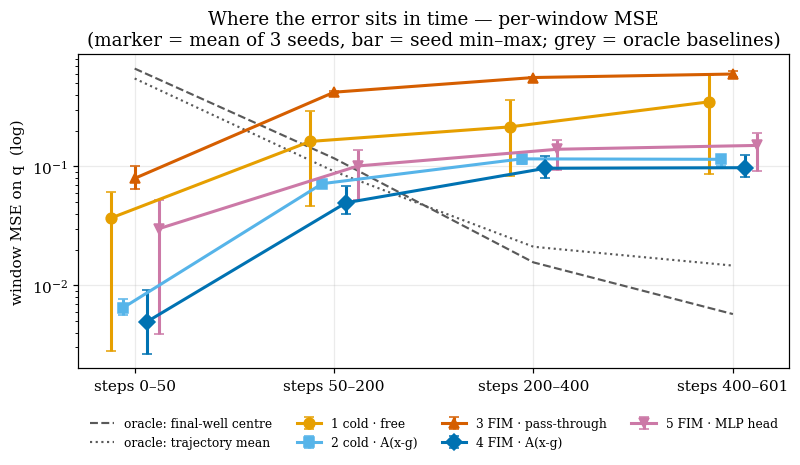

In [7]:
from ftnode.physical.metrics import WINDOWS, rollout_metrics
from ftnode.systems import DuffingDataConfig, make_dataset

# Oracle baselines on the same pooled test split (seeds 1000-1004).
base = DuffingDataConfig(n_traj=64, L=600, tau=8, h=0.05, u_range=0.25, x_range=1.6, delta=0.2, seed=1)
Y = np.concatenate([make_dataset(DuffingDataConfig(**{**base.__dict__, "seed": ts})).Y.numpy()
                    for ts in fac["test_seeds"]])
ORACLE = {"oracle: final-well centre": rollout_metrics(np.repeat(np.sign(Y[:, 400:].mean(1, keepdims=True)), Y.shape[1], 1), Y),
          "oracle: trajectory mean": rollout_metrics(np.repeat(Y.mean(1, keepdims=True), Y.shape[1], 1), Y)}
WKEYS = [f"mse_{a}-{b if b is not None else Y.shape[1]}" for a, b in WINDOWS]
WLAB = [k[4:].replace("-", "–") for k in WKEYS]

fig, ax = plt.subplots(figsize=(7.6, 4.4))
xw = np.arange(len(WKEYS))
for (name, m), ls in zip(ORACLE.items(), ["--", ":"]):
    ax.plot(xw, [m[k] for k in WKEYS], ls, color="0.35", lw=1.4, label=name, zorder=1)
for j, c in enumerate(CELLS):
    v = np.array([per_seed(c, k) for k in WKEYS])          # (window, seed)
    off = (j - 2) * 0.06
    ax.errorbar(xw + off, v.mean(1), yerr=[v.mean(1) - v.min(1), v.max(1) - v.mean(1)],
                color=CELL_COLOR[c], marker=CELL_MARK[c], ms=7, lw=2, capsize=3,
                label=CELL_LABEL[c], zorder=3)
ax.set_yscale("log")
ax.set_xticks(xw); ax.set_xticklabels([f"steps {w}" for w in WLAB])
ax.set_ylabel("window MSE on q  (log)")
ax.set_title("Where the error sits in time — per-window MSE\n(marker = mean of 3 seeds, bar = seed min–max; grey = oracle baselines)")
ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout(); plt.show()

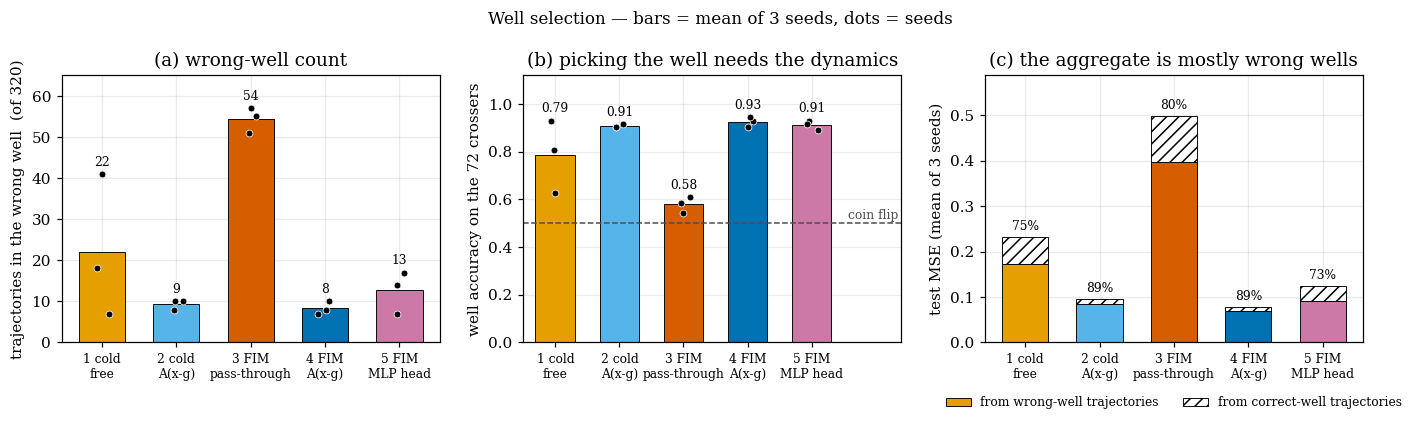

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0))
xc = np.arange(len(CELLS)); short = [CELL_LABEL[c].split(" · ")[0] + "\n" + CELL_LABEL[c].split(" · ")[1]
                                     for c in CELLS]
rng = np.random.default_rng(1)

def bars_with_seeds(ax, key, scale=1.0, fmt="{:.2f}"):
    for i, c in enumerate(CELLS):
        v = per_seed(c, key) * scale
        ax.bar(i, v.mean(), color=CELL_COLOR[c], edgecolor="k", linewidth=0.6, width=0.62, zorder=2)
        ax.scatter(i + (rng.random(3) - 0.5) * 0.2, v, color="k", s=20, zorder=4, edgecolor="w", lw=0.5)
        ax.text(i, v.max() + 0.02 * ax.get_ylim()[1], fmt.format(v.mean()), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(xc); ax.set_xticklabels(short, fontsize=8)

ax = axes[0]; ax.set_ylim(0, 65)
bars_with_seeds(ax, "wrong_wells", fmt="{:.0f}")
ax.set_ylabel("trajectories in the wrong well  (of 320)")
ax.set_title("(a) wrong-well count")

ax = axes[1]; ax.set_ylim(0, 1.12)
bars_with_seeds(ax, "well_acc_crossers")
ax.axhline(0.5, color="0.3", ls="--", lw=1); ax.set_xlim(-0.5, 5.4)
ax.text(5.35, 0.52, "coin flip", ha="right", fontsize=8, color="0.3")
ax.set_ylabel("well accuracy on the 72 crossers")
ax.set_title("(b) picking the well needs the dynamics")

# (c) the aggregate MSE split into the wrong-well part and the correct-well part
ax = axes[2]
tot = np.array([per_seed(c, "mse").mean() for c in CELLS])
share = np.array([per_seed(c, "wrong_well_error_share").mean() for c in CELLS])
ax.bar(xc, tot * share, width=0.62, color=[CELL_COLOR[c] for c in CELLS], edgecolor="k", lw=0.6,
       label="from wrong-well trajectories", zorder=2)
ax.bar(xc, tot * (1 - share), bottom=tot * share, width=0.62, color="white", edgecolor="k", lw=0.6,
       hatch="///", label="from correct-well trajectories", zorder=2)
for i in xc:
    ax.text(i, tot[i] + 0.01, f"{100 * share[i]:.0f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(xc); ax.set_xticklabels(short, fontsize=8)
ax.set_ylabel("test MSE (mean of 3 seeds)"); ax.set_ylim(0, tot.max() * 1.18)
ax.set_title("(c) the aggregate is mostly wrong wells")
ax.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16), frameon=False)
fig.suptitle("Well selection — bars = mean of 3 seeds, dots = seeds", fontsize=11)
plt.tight_layout(); plt.show()

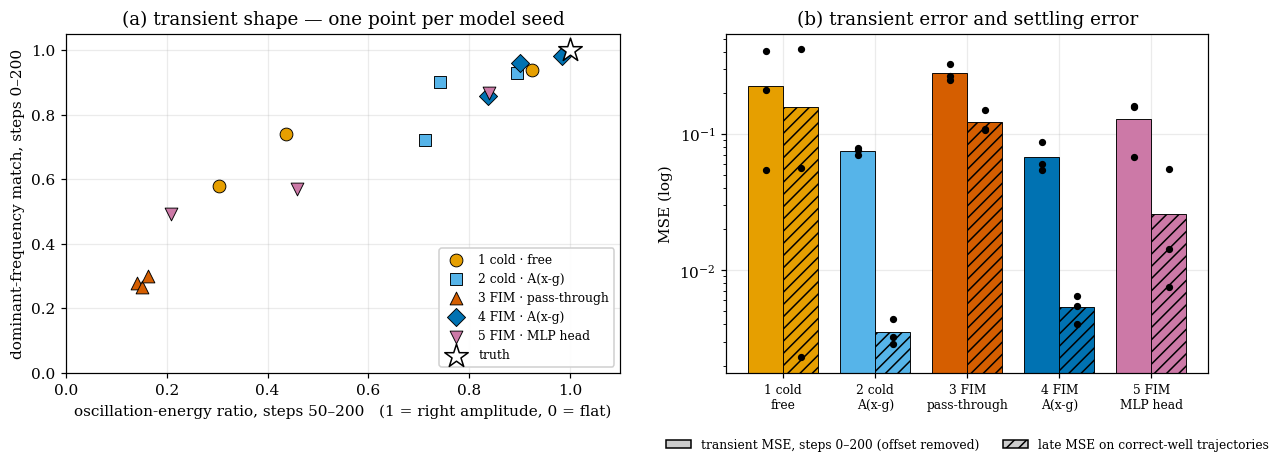

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
for c in CELLS:
    ax.scatter(per_seed(c, "osc_energy_ratio"), per_seed(c, "dom_freq_match"), s=70,
               marker=CELL_MARK[c], color=CELL_COLOR[c], edgecolor="k", lw=0.6, label=CELL_LABEL[c], zorder=3)
ax.scatter([1], [1], marker="*", s=260, color="w", edgecolor="k", lw=1.0, zorder=4, label="truth")
ax.set_xlim(0, 1.1); ax.set_ylim(0, 1.05)
ax.set_xlabel("oscillation-energy ratio, steps 50–200   (1 = right amplitude, 0 = flat)")
ax.set_ylabel("dominant-frequency match, steps 0–200")
ax.set_title("(a) transient shape — one point per model seed")
ax.legend(fontsize=8, loc="lower right", framealpha=0.92)

ax = axes[1]
xc = np.arange(len(CELLS)); w = 0.38
for i, c in enumerate(CELLS):
    tr, late = per_seed(c, "transient_mse"), per_seed(c, "late_mse_correct_wells")
    ax.bar(i - w / 2, tr.mean(), w, color=CELL_COLOR[c], edgecolor="k", lw=0.6, zorder=2)
    ax.bar(i + w / 2, late.mean(), w, color=CELL_COLOR[c], edgecolor="k", lw=0.6, hatch="///", zorder=2)
    ax.scatter(np.full(3, i - w / 2), tr, color="k", s=14, zorder=4)
    ax.scatter(np.full(3, i + w / 2), late, color="k", s=14, zorder=4)
ax.set_yscale("log")
ax.set_xticks(xc); ax.set_xticklabels([CELL_LABEL[c].replace(" · ", "\n") for c in CELLS], fontsize=8)
ax.set_ylabel("MSE (log)")
from matplotlib.patches import Patch
ax.legend([Patch(facecolor="0.8", edgecolor="k"), Patch(facecolor="0.8", edgecolor="k", hatch="///")],
          ["transient MSE, steps 0–200 (offset removed)", "late MSE on correct-well trajectories"],
          fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16), frameon=False)
ax.set_title("(b) transient error and settling error")
plt.tight_layout(); plt.show()

In [10]:
import pandas as pd
cols = {"mse": "test MSE", "mse_0-50": "e 0–50", "wrong_wells": "wrong wells /320",
        "well_acc_crossers": "well acc. crossers", "wrong_well_error_share": "wrong-well share",
        "late_mse_correct_wells": "late MSE, correct wells", "transient_mse": "transient MSE",
        "osc_energy_ratio": "osc. energy", "dom_freq_match": "freq. match"}
rows = []
for name, m in ORACLE.items():
    rows.append({"cell": name, "seed": "—", **{v: m[k] for k, v in cols.items()}})
for c in CELLS:
    for s in SEED_KEYS:
        rows.append({"cell": CELL_LABEL[c], "seed": s, **{v: M[c][s][k] for k, v in cols.items()}})
table = pd.DataFrame(rows).set_index(["cell", "seed"])
table.style.format("{:.3f}").format("{:.0f}", subset=["wrong wells /320"])

### Experiment 1 — reading

Measured on 3 seeds, test seeds 1000–1004:

1. **The trained structured cells track the transient.** $e_{0:50}$ is $0.003$–$0.009$ against
   $0.55$–$0.67$ for the oracles, and they keep 71–98% of the oscillation energy. The score does not
   only reward a settle into the correct well.
2. **The aggregate score is mostly a wrong-well count.** About 88–91% of a structured cell's squared
   error comes from the 2–3% of trajectories that settle in the wrong well; on correct-well trajectories
   the late MSE is $0.003$–$0.007$.
3. **Cell 4 and cell 2 do not separate** (wrong wells 7/10/8 vs 10/8/10; $c_4-c_2$ = −0.037, +0.014,
   −0.030). "FIM + structure beats cold + structure" is not resolved at 3 seeds.
4. **The cell-3 collapse is a design artifact, not the absence of structure.** Cell 3 over-damps
   (energy 0.14–0.16), picks the well at coin-flip level on crossers, and settles off target. The matched
   MLP head on the same FIM feature mostly avoids this ($\text{pass-through}=c_3-c_5=+0.374\pm0.038$).
   This run cannot tell whether the pass-through or the missing direct $u$ input is the cause.
5. **The original synergy does not survive.** $(c_4-c_3)-(c_2-c_1)=-0.284$ is carried by the cell-3
   collapse. Against cell 5 the interaction is $+0.090\pm0.118$ — noise. Structure helps a cold field
   ($-0.137$) at least as much as a FIM field.
6. **Structure helps a FIM field modestly and on every seed, mainly through reliability.**
   $c_4-c_5=-0.047\pm0.027$ (per seed −0.011, −0.052, −0.078), and cell 4 is ahead on every metric.
   Cell 4 keeps 84–98% of the oscillation energy on every seed; cell 5 matches it only on seed 0
   (best epoch 469) — its seeds 1 and 2 stop early (best epochs 134, 56) and over-damp (0.46, 0.21).
   These seeds do not show a higher best-case fit from the structure.
7. **Gate reading: the structure meshes with a FIM field.** The structured FIM cell is best or tied on
   every metric and the most consistent across seeds, with no sign of conflict. "Structure makes
   pretraining useful" is not supported. The far-field limit (Experiment 2) still stands for a
   structure-as-backbone model.

## Experiment 2 — the quick retune (mechanism probe)

Cheap CPU proof-of-concept (`scripts/fim_quick_retune.py`, `ftnode/fim/quick.py`):
$n_{\text{traj}}=12$, seed 0. **Different metric** — pointwise drift MSE against the *true*
field over visited states, no integration:

$$\text{driftMSE}=\operatorname{mean}_{\text{traj},t,\dim}\big\|F_{\text{model}}(x,u)-f^*(x,u)\big\|^2,\qquad x=\texttt{Xfull}[:,t,:].$$

**Quick cell 3 (reference).** *zero-shot* = raw `FIMBackbone.drift`, no training.
*retuned* = `FreeFIMField` trained by a **short** rollout only, $L_{\text{short}}=6$:
`estimate_x0` → 6 RK4 steps → loss $\operatorname{mean}(\hat q-y)^2$ on the first 7 $q$;
40 epochs, backbone lr $5\times10^{-6}$ (minimal BPTT).

**Quick cell 4 (the PoC — distillation, no rollout).** Freeze the whole zero-shot backbone;
precompute the detached target $f_{\text{FIM}}(x)$ at every visited state; fit only the
structured heads $L,S,g$ by pointwise regression

$$\min\ \operatorname{mean}\big\|A(x)(x-g(x,u))-f_{\text{FIM}}(x)\big\|^2,\qquad \text{feat}=[f_{\text{FIM}}(x),x],\ 60\ \text{epochs}.$$

$A$ stays negative definite by construction throughout. Then an *optional* head-only finetune
(6-step $q$-rollout, backbone frozen, 20 epochs) — a **different objective** (integral vs
pointwise). Evaluation adds a grid over $2.5\times$ the visited box, split in-region /
out-of-region, to expose the far-field.

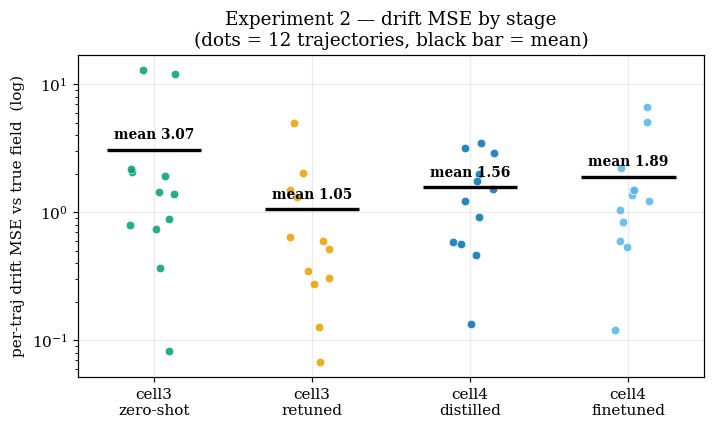

In [11]:
stages = [("cell3_zero_shot", "cell3\nzero-shot", C_FIM),
          ("cell3_retuned",   "cell3\nretuned",   C_FREE),
          ("cell4_distilled", "cell4\ndistilled", C_STRUCT),
          ("cell4_finetuned", "cell4\nfinetuned", "#56B4E9")]

fig, ax = plt.subplots(figsize=(6.6, 4.0))
rng = np.random.default_rng(0)
for i, (k, lbl, c) in enumerate(stages):
    pts = np.array(quick[k]["per_traj"])
    jit = (rng.random(len(pts)) - 0.5) * 0.30
    ax.scatter(i + jit, pts, color=c, s=30, alpha=0.85, edgecolor="w", linewidth=0.4, zorder=3)
    m = quick[k]["mean"]
    ax.hlines(m, i - 0.30, i + 0.30, color="k", linewidth=2.2, zorder=4)
    ax.text(i, m * 1.15, f"mean {m:.2f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", zorder=5)
ax.set_yscale("log")
ax.set_xticks(range(4)); ax.set_xticklabels([l for _, l, _ in stages])
ax.set_ylabel("per-traj drift MSE vs true field  (log)")
ax.set_title("Experiment 2 — drift MSE by stage\n(dots = 12 trajectories, black bar = mean)")
plt.tight_layout(); plt.show()

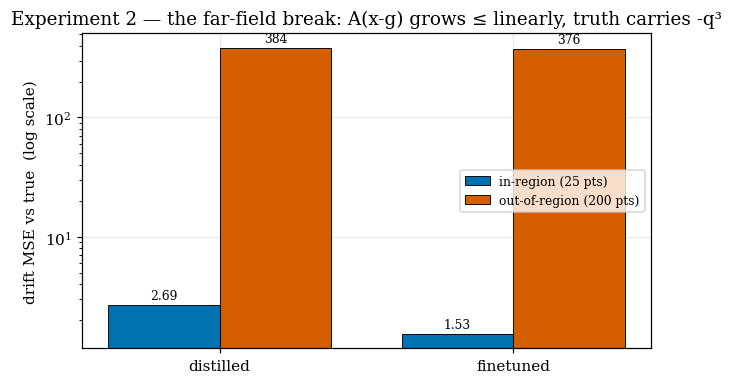

In [12]:
gd = quick["cell4_distilled"]["grid"]; gf = quick["cell4_finetuned"]["grid"]
groups = ["distilled", "finetuned"]
inr = [gd["in_region_mse"], gf["in_region_mse"]]
out = [gd["out_region_mse"], gf["out_region_mse"]]

fig, ax = plt.subplots(figsize=(6.0, 3.6))
x = np.arange(2); w = 0.38
b1 = ax.bar(x - w/2, inr, w, label=f"in-region ({gd['in_points']} pts)",
            color=C_STRUCT, edgecolor="k", linewidth=0.6)
b2 = ax.bar(x + w/2, out, w, label=f"out-of-region ({gd['out_points']} pts)",
            color="#D55E00", edgecolor="k", linewidth=0.6)
ax.bar_label(b1, fmt="%.2f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.0f", fontsize=8, padding=2)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("drift MSE vs true  (log scale)")
ax.set_title("Experiment 2 — the far-field break: A(x-g) grows ≤ linearly, truth carries -q³")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

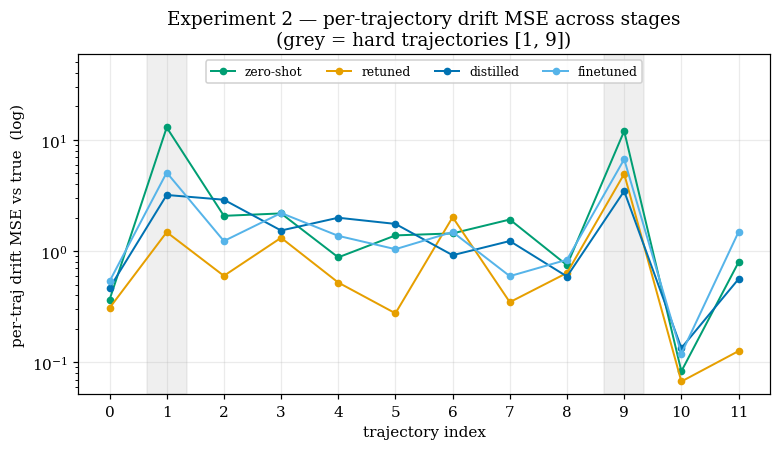

In [13]:
pt = {k: np.array(quick[k]["per_traj"]) for k in
      ["cell3_zero_shot", "cell3_retuned", "cell4_distilled", "cell4_finetuned"]}
fig, ax = plt.subplots(figsize=(7.2, 4.2))
xs = np.arange(12)
for (k, lbl, c) in [("cell3_zero_shot", "zero-shot", C_FIM),
                    ("cell3_retuned", "retuned", C_FREE),
                    ("cell4_distilled", "distilled", C_STRUCT),
                    ("cell4_finetuned", "finetuned", "#56B4E9")]:
    ax.plot(xs, pt[k], "o-", color=c, label=lbl, linewidth=1.3, markersize=4)
hard = [int(i) for i in xs if pt["cell3_zero_shot"][i] > 8]
for i in hard:
    ax.axvspan(i - 0.35, i + 0.35, color="grey", alpha=0.12, zorder=0)
ax.set_yscale("log")
ax.set_xticks(xs)
ax.set_xlabel("trajectory index"); ax.set_ylabel("per-traj drift MSE vs true  (log)")
ax.set_title(f"Experiment 2 — per-trajectory drift MSE across stages\n(grey = hard trajectories {hard})")
ax.set_ylim(top=ax.get_ylim()[1] * 3.5)  # headroom so the legend clears the traces
ax.legend(fontsize=8, ncol=4, loc="upper center", framealpha=0.9)
plt.tight_layout(); plt.show()

### Experiment 2 — run time (CPU) and reading

All four stages run on **CPU** (Threadripper 3960X), single seed:

| stage | wall-clock |
|---|---|
| cell 3 zero-shot (eval only) | ~0.8 s |
| cell 3 short-rollout retune (40 ep) | ~44 s |
| cell 4 distillation (60 ep) | ~3.8 s |
| cell 4 optional finetune (20 ep) | ~15 s |

(The cell below reads these from `report.json` directly.)

**Reading.** (1) The pretrained FIM **retunes cheaply** — drift MSE $3.07\to1.05$ in ~44 s.
(2) The bounded structure **carries the field only locally**: distillation floors near $0.80$
and its residual to the FIM drift is $1.83$ even in-region — the caps
($\operatorname{sym}A\preceq-\sigma_{\min}I$, $g\in[-2,2]^2$) cannot fully match FIM.
(3) The **far-field breaks**: $\|A(x)(x-g)\|\le\|A\|\,\|x-g\|$ grows *at most linearly* while
the true acceleration carries $-q^3$; out-of-region grid MSE $384$ vs $2.69$ in-region
(≈140×). At $q\approx4$ truth is $O(60)$, structure $O(10)$. This is a representability ceiling
of the construction, not a training failure. (4) The post-distill finetune is a wash-to-negative
— it lowers in-region grid error ($2.69\to1.53$) but raises drift MSE ($1.56\to1.89$), because
a short rollout is a weak integral constraint that lets the two hard trajectories degrade.

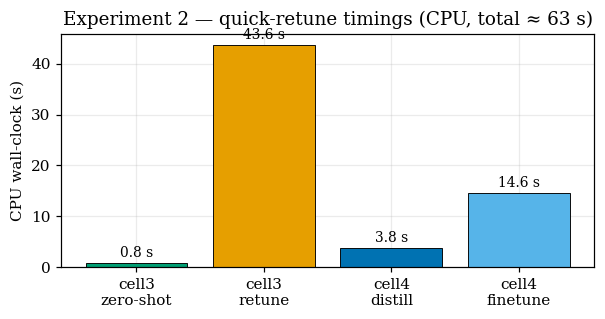

In [14]:
t = quick["timings_s"]
names = ["cell3\nzero-shot", "cell3\nretune", "cell4\ndistill", "cell4\nfinetune"]
vals = [t["cell3_zero_shot"], t["cell3_retune"], t["cell4_distill"], t["cell4_finetune"]]
fig, ax = plt.subplots(figsize=(5.6, 3.0))
b = ax.bar(names, vals, color=[C_FIM, C_FREE, C_STRUCT, "#56B4E9"],
           edgecolor="k", linewidth=0.6)
ax.bar_label(b, fmt="%.1f s", fontsize=9, padding=2)
ax.set_ylabel("CPU wall-clock (s)")
ax.set_title(f"Experiment 2 — quick-retune timings (CPU, total ≈ {sum(vals):.0f} s)")
plt.tight_layout(); plt.show()

## Note — the saturation check that set the bar (run first, 2026-09-11)

Before the FIM arm, the incumbent **latent** identifier `l-ft-k-svd-clamp` was re-run at a
**longer schedule, 200 → 600 epochs** (`experiments/duffing/kappa_sat.yaml`; schedule
$T_{\max}=n_{\text{epochs}}$, so the 600-epoch run contains its own matched first-200 segment).
The verdict reads the validation floor within one run, so there is no cross-run confound:

$$\text{improved}=\min_{t\le200}\mathrm{val}(t)-\min_{200<t\le600}\mathrm{val}(t).$$

**Result — truncated, not saturated.** On all 10 seeds the within-run floor drops from
$\sim0.009\text{–}0.064$ (first 200) to $\sim0.0012\text{–}0.0029$ (epochs 200–600), best epochs
at 493–583. Held-out test MSE median $\approx0.028$ vs $\approx0.081$ for the committed 200-epoch
run; the paired difference is negative on every seed. Side finding: the long schedule
*destabilises* the **unbounded** operator (4 seeds collapse) while the $\kappa$-bounded operators
tolerate it — a structural signal.

**Why it matters here.** The incumbent was *undertrained*, not at a class ceiling. So a FIM
warm-start must beat the **600-epoch bar, ≈ 0.028 test MSE** — not the weaker 200-epoch one. But
that bar is a *latent-pipeline* number and is **not** directly comparable to Experiment 1's
physical-state scores — see the next cell for exactly why.

## Why the physical-state MSE is not comparable to the latent 0.028 bar

Both numbers are a held-out **$q$-MSE over an $L=600$ rollout, on the same test seeds (1000–100$x$),
on the same Duffing plant** ($\delta=0.2$, $u\in[-0.25,0.25]$, $x_{\text{range}}=1.6$, $\tau=8$) —
the trajectory distribution is *identical* (both use the `DuffingDataConfig` defaults). They are
still **not on the same axis**, because the map that produces $\hat q$ differs:

| | latent (the $0.028$ bar) | physical-state (Experiment 1) |
|---|---|---|
| pipeline | window $\to$ **encoder** $\to z\in\mathbb R^{4}$ $\to A(z)(z-g)\to$ **linear decoder** $\to\hat q$ | finite-diff $x_0\in\mathbb R^{2}\to A(x)(x-g)\to$ readout $\hat q=x_0$ |
| state dim | $m=4$ (2 extra learned dims) | $m=2$ (true phase space) |
| initial condition | learned from the whole $\tau$-window (rich) | parameter-free 2-point finite difference (fixed, lossy) |
| residual reg $\lambda_{\text{res}}$ | $10^{-2}$ (on) | $0$ (off) |
| statistic quoted | median over 10 seeds, 600 epochs | per-cell mean over 3 seeds |

Three of these lift the physical scores *independently of field quality*: **(i)** the physical cell
discards the window and starts from a fixed, lossy $x_0$ estimate, paying an init-error floor the
encoder avoids; **(ii)** it is pinned to the true 2-D phase space, with no extra latent dimensions to
absorb observation lag or model error; **(iii)** it is the deliberately **minimal** pipeline — no
encoder, no decoder — chosen so the factorial isolates *structure × pretraining*, not to win on
absolute MSE.

So $0.078$ (physical, best cell) and $0.028$ (latent) measure fit through **different observation
models**; the gap is mostly pipeline, not prior or field quality. A fair cross-pipeline comparison —
e.g. wrapping an encoder/decoder around the FIM field, or scoring the latent field under the physical
minimal-init protocol — is still owed before any go/no-go on a structured foundation model.

## Summary

- **The structure meshes with a foundation model.** Against the matched FIM + MLP head (cell 5), the
  bounded $A(x-g)$ lowers test MSE on every seed ($-0.047$), wins every metric, and makes training
  reliable. *(Exp 1)*
- **No synergy.** The earlier interaction $-0.284$ was an artifact of the cell-3 design (drift
  pass-through, no direct $u$), which collapses on every seed; the matched interaction is noise
  ($+0.090\pm0.118$). *(Exp 1)*
- **The aggregate MSE is mostly a wrong-well count** — read it with the metric set, not alone. *(Exp 1)*
- **The mechanism is a bounded, local, stable fit.** FIM retunes cheaply; the structure carries it
  in-region but the cubic far-field breaks it (out-region drift MSE $384$). *(Exp 2)*
- **The bar is $\approx0.028$** (600-epoch latent), and the incumbent had real headroom, but the
  physical-state scores here are on a different axis. *(Saturation note)*

**Open questions.** (1) Which cell-3 difference causes its collapse — the pass-through or the missing
direct $u$? (a cell-3 + $u$ variant separates them). (2) Does a rollout finetune of the structured head
help or hurt? (3) The right cross-pipeline comparison against the $0.028$ latent bar before any go/no-go.
(4) Is the cell-5 seed spread optimisation (early stop) or real? More seeds or longer patience.
(5) How much of the cubic far-field can a bounded $A(x-g)$ backbone represent — the question that
decides the structure-as-backbone foundation model.

## Rollout trajectories — true vs model $q(t)$

The final check: rebuild each cell from its saved checkpoints
(`runs/fim_factorial/<cell>/seed<N>.pth`), roll out $L=600$ on a held-out test set
(seed 1000), and overlay the model's $\hat q(t)$ against the true $q(t)$. One panel per cell,
3 trajectories each. **Black dashed** = true $q(t)$; **coloured solid** = model prediction
(mean over the 3 model seeds); the **shaded band** is the seed min–max envelope. FIM cells
re-run the 13M backbone inside the rollout, so this cell takes a few minutes on CPU. Each panel is
auto-scaled to the true amplitude (×2.5), so a diverging cell may clip — that clipping *is* the failure.

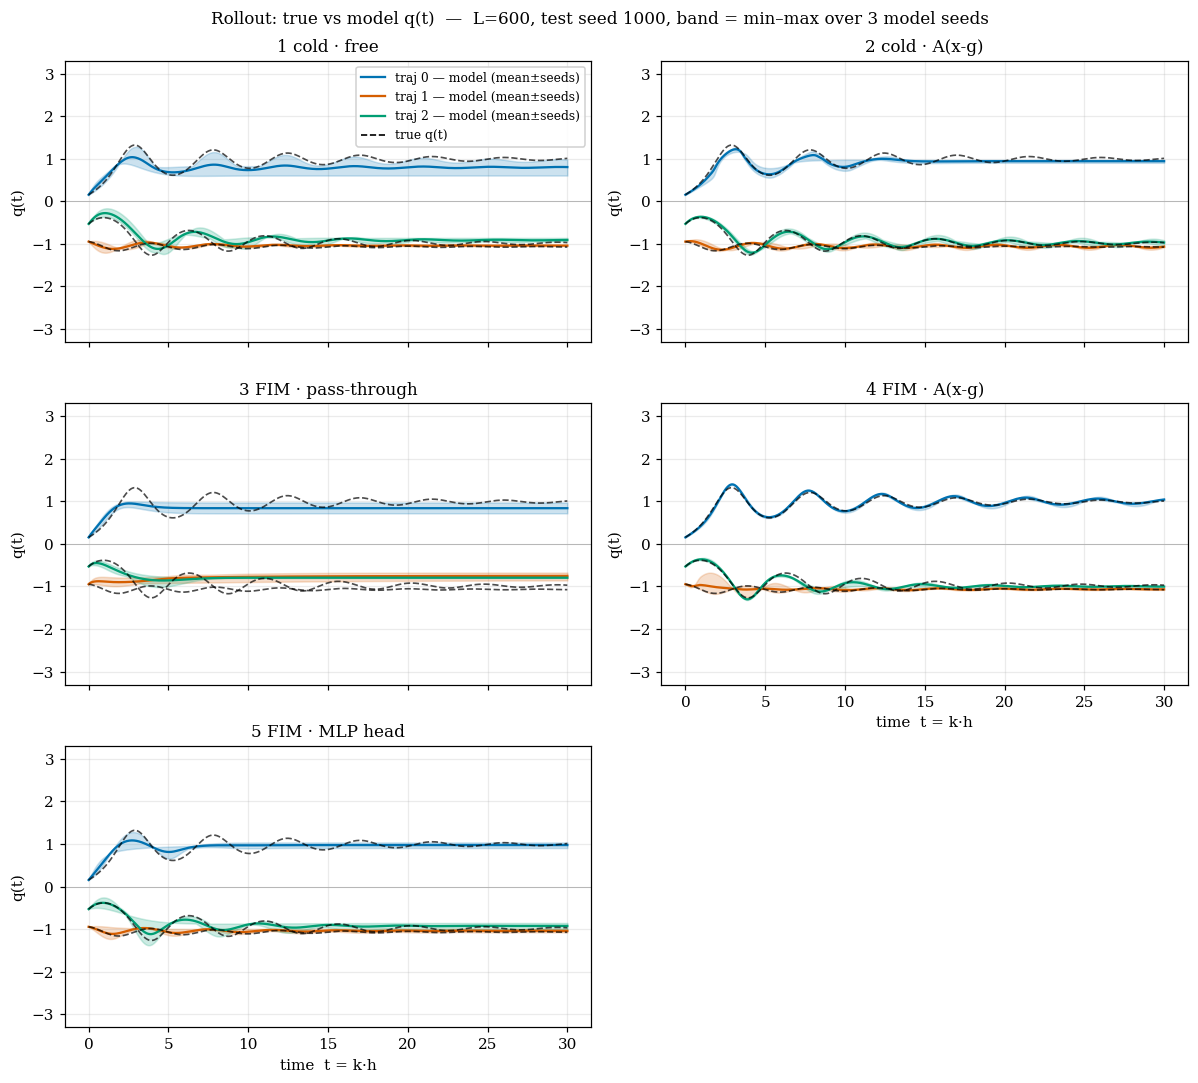

In [15]:
import torch
from matplotlib.lines import Line2D
from ftnode.physical.config import (PhysicalConfig, build_cold_unstructured,
    build_cold_structured, build_fim_unstructured, build_fim_structured, build_fim_mlp_head)
from ftnode.physical.train import rollout_q
from ftnode.fim import FIMBackbone
from ftnode.systems import DuffingDataConfig, make_dataset

DEV, H, TAU, L_TRAJ = "cpu", 0.05, 8, 600
SEEDS, TRAJ = [0, 1, 2], [0, 1, 2]           # model seeds; held-out trajectories to show
mcfg = PhysicalConfig(tau=TAU, h=H)
test = DuffingDataConfig(n_traj=8, L=L_TRAJ, tau=TAU, h=H,
                         u_range=0.25, x_range=1.6, delta=0.2, seed=1000)
ds = make_dataset(test).to(DEV)
t = np.arange(L_TRAJ + 1) * H
Ytrue = ds.Y.cpu().numpy()

shared_bb = FIMBackbone.from_pretrained(device=DEV, state_dim=mcfg.m)   # reused across FIM builds/seeds

PANELS = [("cold-unstructured", lambda: build_cold_unstructured(mcfg)),
          ("cold-structured",   lambda: build_cold_structured(mcfg)),
          ("fim-unstructured",  lambda: build_fim_unstructured(mcfg, shared_bb)),
          ("fim-structured",    lambda: build_fim_structured(mcfg, shared_bb)),
          ("fim-mlp-head",      lambda: build_fim_mlp_head(mcfg, shared_bb))]

def preds_for(name, build):
    out = []
    for s in SEEDS:
        torch.manual_seed(s)                                  # match head-init RNG (overwritten by load)
        m = build().to(DEV)
        m.load_state_dict(torch.load(ROOT / f"runs/fim_factorial/{name}/seed{s}.pth", map_location=DEV))
        m.eval()
        with torch.no_grad():
            if hasattr(m, "prepare"):
                m.prepare(ds.W)
            out.append(rollout_q(m, ds.W, ds.U, L_TRAJ, H).cpu().numpy())
    return np.stack(out)                                      # (n_seed, n_traj, L+1)

traj_colors = ["#0072B2", "#D55E00", "#009E73"]
A = 2.5 * np.abs(Ytrue[TRAJ]).max()                           # per-panel y-cap, true amplitude x2.5
fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex=True)
for ax, (name, build) in zip(axes.ravel(), PANELS):
    title = CELL_LABEL[name]
    P = preds_for(name, build)
    for j, tr in enumerate(TRAJ):
        c = traj_colors[j]
        ax.plot(t, Ytrue[tr], "k--", lw=1.1, alpha=0.7, zorder=3)
        ax.fill_between(t, P[:, tr].min(0), P[:, tr].max(0), color=c, alpha=0.20, zorder=1)
        ax.plot(t, P[:, tr].mean(0), color=c, lw=1.5, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("q(t)"); ax.set_ylim(-A, A); ax.axhline(0, color="0.7", lw=0.6)
for ax in axes[2]:
    ax.set_xlabel("time  t = k·h")
axes[2, 1].set_visible(False)
axes[1, 1].tick_params(labelbottom=True)
axes[1, 1].set_xlabel("time  t = k·h")
handles = [Line2D([0], [0], color=traj_colors[j], lw=1.5) for j in range(len(TRAJ))] + \
          [Line2D([0], [0], color="k", ls="--", lw=1.1)]
labels = [f"traj {tr} — model (mean±seeds)" for tr in TRAJ] + ["true q(t)"]
axes[0, 0].legend(handles, labels, fontsize=8, loc="upper right", framealpha=0.9)
fig.suptitle("Rollout: true vs model q(t)  —  L=600, test seed 1000, band = min–max over 3 model seeds",
             fontsize=11)
plt.tight_layout(); plt.show()

## The data — training, validation, and test splits

All splits come from one generator (`ftnode.systems.make_dataset`) and differ **only in the seed
and the horizon**. Per trajectory: an initial state is drawn uniformly from
$[-1.6,1.6]\times[-1,1]$ in $(q,\dot q)$, a constant input $u\sim\mathcal U[-0.25,0.25]$ is drawn and
held, and the Duffing ODE is integrated on the grid $h=0.05$. The first $\tau=8$ samples of $q$
(0.4 s) form the window $W$ the model sees. The rollout starts at the next sample, so the
initial state *of the rollout* is the drawn state advanced by 0.4 s, not the drawn state itself.
$\dot q$ is simulated but never shown to any model.

| split | seed(s) | trajectories | rollout steps $L$ | horizon | used for |
|---|---|---|---|---|---|
| train | 0 | 512 | 200 | 10 s | the 200-step $q$-rollout loss |
| validation | 1 | 64 | 600 | 30 s | early-stop and checkpoint selection |
| test | 1000–1004 | 5 × 64 = 320 | 600 | 30 s | every score in this notebook |

Two properties matter for reading the scores. **The test horizon is 3× the training horizon**, so
steps 200–600 are an extrapolation in time: no training loss ever saw them. And the input
distribution and initial-state box are **identical** across splits, so the test is in-distribution
in state and input — the far-field of Experiment 2 is never probed here. The cells below give the
statistics and the coverage.

In [16]:
import pandas as pd
from ftnode.systems import DuffingDataConfig, make_dataset

GEOM = dict(tau=8, h=0.05, u_range=0.25, x_range=1.6, delta=0.2)
SPLITS = {
    "train": [make_dataset(DuffingDataConfig(n_traj=512, L=200, seed=0, **GEOM))],
    "validation": [make_dataset(DuffingDataConfig(n_traj=64, L=600, seed=1, **GEOM))],
    "test": [make_dataset(DuffingDataConfig(n_traj=64, L=600, seed=s, **GEOM)) for s in range(1000, 1005)],
}
DATA = {k: dict(Y=np.concatenate([d.Y.numpy() for d in v]),
                X=np.concatenate([d.Xfull.numpy() for d in v]),
                U=np.concatenate([d.U.numpy() for d in v])) for k, v in SPLITS.items()}
TRAIN_STEPS = 200
C_SPLIT = {"train": "#0072B2", "validation": "#999999", "test": "#D55E00"}

def split_stats(d):
    Y, X, U = d["Y"], d["X"], d["U"]
    L = Y.shape[1] - 1
    well = np.sign(Y[:, -50:].mean(1))                      # final well: sign over the last 50 steps
    early = np.sign(Y[:, :20].mean(1))
    at200 = np.sign(Y[:, min(TRAIN_STEPS, L) - 20: min(TRAIN_STEPS, L)].mean(1))
    dev = np.abs(Y - well[:, None])
    return {
        "trajectories": len(Y), "rollout steps": L, "horizon (s)": L * 0.05,
        "u min": U.min(), "u max": U.max(), "u mean": U.mean(),
        "q range": f"[{Y.min():+.2f}, {Y.max():+.2f}]",
        "q̇ range": f"[{X[..., 1].min():+.2f}, {X[..., 1].max():+.2f}]",
        "end in well +1 (%)": 100 * (well > 0).mean(),
        "change well (%)": 100 * (early != well).mean(),
        "still switching after step 200 (%)": 100 * (at200 != well).mean() if L > TRAIN_STEPS else np.nan,
        "|q − well| at end, median": np.median(dev[:, -1]),
        "steps with |q − well| > 0.1 (%)": 100 * (dev > 0.1).mean(),
    }

stats = pd.DataFrame({k: split_stats(d) for k, d in DATA.items()})
stats

,train,validation,test
trajectories,512,64,320
rollout steps,200,600,600
horizon (s),10.0,30.0,30.0
u min,-0.24985,-0.241639,-0.248556
u max,0.249751,0.240369,0.2454
u mean,-0.004071,0.019817,-0.004085
q range,"[-1.70, +1.67]","[-1.57, +1.59]","[-1.67, +1.68]"
q̇ range,"[-1.33, +1.27]","[-1.15, +1.07]","[-1.14, +1.34]"
end in well +1 (%),51.171875,54.6875,45.9375
change well (%),24.609375,29.6875,22.5


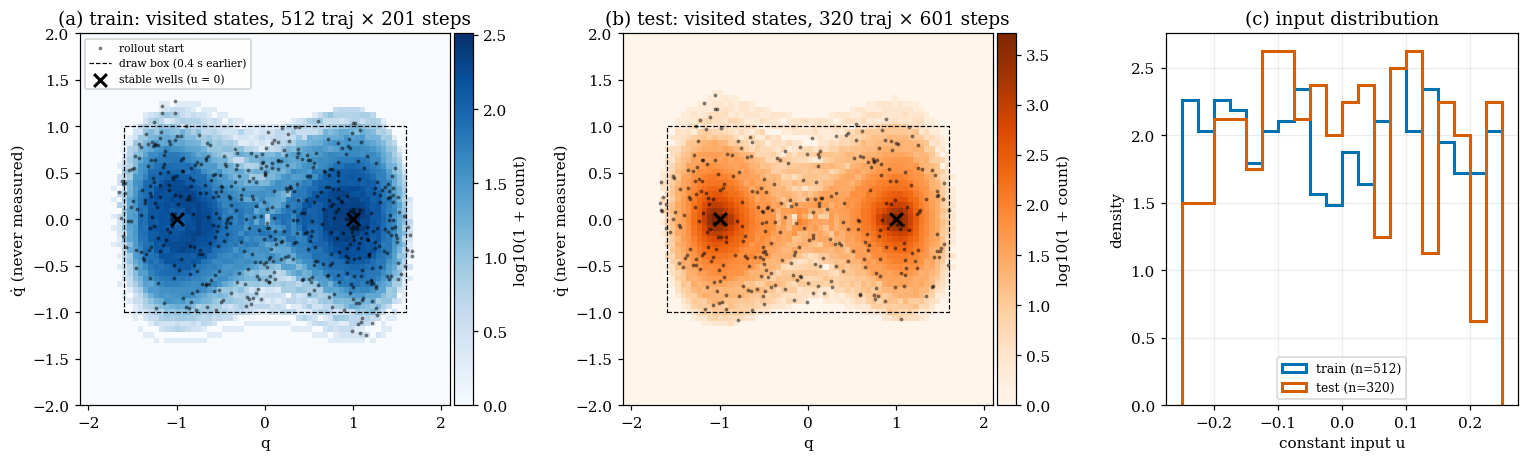

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.3), gridspec_kw={"width_ratios": [1, 1, 0.8]})
edges_q, edges_v = np.linspace(-2.1, 2.1, 71), np.linspace(-2.0, 2.0, 67)
for ax, name, cmap in [(axes[0], "train", "Blues"), (axes[1], "test", "Oranges")]:
    X = DATA[name]["X"]
    Hh, _, _ = np.histogram2d(X[..., 0].ravel(), X[..., 1].ravel(), bins=[edges_q, edges_v])
    im = ax.pcolormesh(edges_q, edges_v, np.log10(1 + Hh.T), cmap=cmap, shading="flat")
    ax.scatter(X[:, 0, 0], X[:, 0, 1], s=6, color="k", alpha=0.5, lw=0, label="rollout start")
    ax.plot([-1.6, 1.6, 1.6, -1.6, -1.6], [-1, -1, 1, 1, -1], color="k", lw=0.8, ls="--",
            label="draw box (0.4 s earlier)")
    ax.scatter([-1, 1], [0, 0], marker="x", s=70, color="k", lw=2, label="stable wells (u = 0)")
    ax.set_xlabel("q"); ax.set_ylabel("q̇ (never measured)")
    ax.set_title(f"({'a' if name == 'train' else 'b'}) {name}: visited states, "
                 f"{X.shape[0]} traj × {X.shape[1]} steps")
    fig.colorbar(im, ax=ax, label="log10(1 + count)", pad=0.01)
axes[0].legend(fontsize=7, loc="upper left", framealpha=0.9)

ax = axes[2]
bins = np.linspace(-0.25, 0.25, 21)
for name in ["train", "test"]:
    ax.hist(DATA[name]["U"], bins=bins, density=True, histtype="step", lw=2, color=C_SPLIT[name],
            label=f"{name} (n={len(DATA[name]['U'])})")
ax.set_xlabel("constant input u"); ax.set_ylabel("density")
ax.set_title("(c) input distribution")
ax.legend(fontsize=8, loc="lower center")
plt.tight_layout(); plt.show()

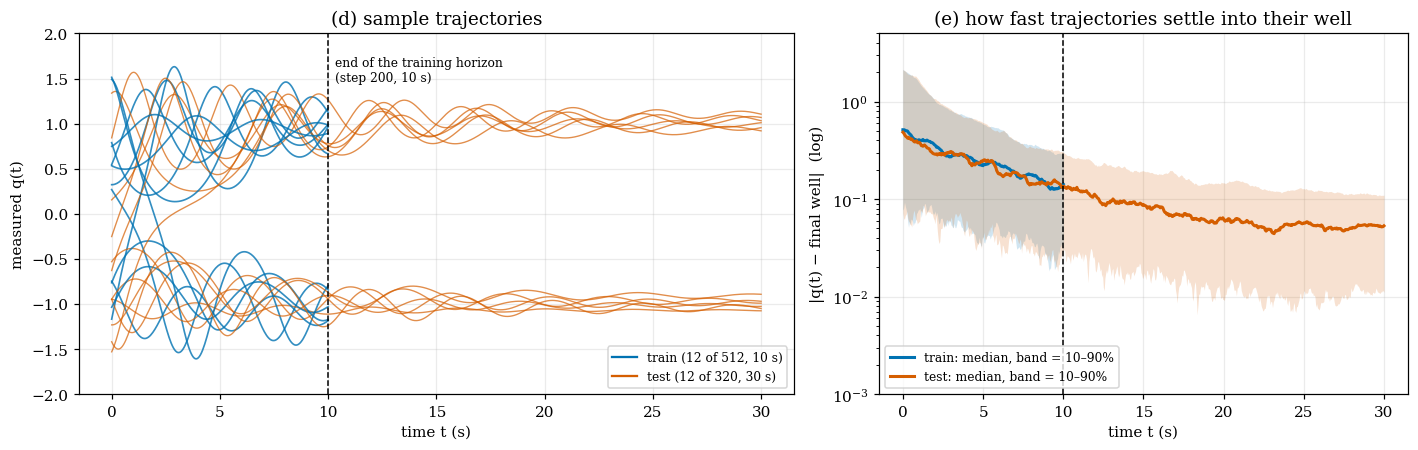

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})
t_te = np.arange(DATA["test"]["Y"].shape[1]) * 0.05
t_tr = np.arange(DATA["train"]["Y"].shape[1]) * 0.05

ax = axes[0]
for i in range(12):
    ax.plot(t_te, DATA["test"]["Y"][i], color=C_SPLIT["test"], lw=0.9, alpha=0.7)
    ax.plot(t_tr, DATA["train"]["Y"][i], color=C_SPLIT["train"], lw=1.1, alpha=0.8)
ax.axvline(TRAIN_STEPS * 0.05, color="k", lw=1, ls="--")
ax.text(TRAIN_STEPS * 0.05 + 0.3, 1.75, "end of the training horizon\n(step 200, 10 s)", fontsize=8, va="top")
ax.set_xlabel("time t (s)"); ax.set_ylabel("measured q(t)"); ax.set_ylim(-2.0, 2.0)
from matplotlib.lines import Line2D
ax.legend([Line2D([0], [0], color=C_SPLIT["train"], lw=1.5), Line2D([0], [0], color=C_SPLIT["test"], lw=1.5)],
          ["train (12 of 512, 10 s)", "test (12 of 320, 30 s)"], fontsize=8, loc="lower right")
ax.set_title("(d) sample trajectories")

ax = axes[1]
for name in ["train", "test"]:
    Y = DATA[name]["Y"]; well = np.sign(Y[:, -50:].mean(1))
    dev = np.abs(Y - well[:, None]); tt = np.arange(Y.shape[1]) * 0.05
    ax.fill_between(tt, np.percentile(dev, 10, 0), np.percentile(dev, 90, 0), color=C_SPLIT[name], alpha=0.18, lw=0)
    ax.plot(tt, np.median(dev, 0), color=C_SPLIT[name], lw=2, label=f"{name}: median, band = 10–90%")
ax.axvline(TRAIN_STEPS * 0.05, color="k", lw=1, ls="--")
ax.set_yscale("log"); ax.set_ylim(1e-3, 5)
ax.set_xlabel("time t (s)"); ax.set_ylabel("|q(t) − final well|  (log)")
ax.set_title("(e) how fast trajectories settle into their well")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**Reading.** The splits share one state box and one input distribution, so the test is in-distribution
in *where* it goes. It differs from training only in *how long* it runs.

- **Every well decision happens inside the training horizon.** No validation or test trajectory changes
  well after step 200. 22–30% change well at some point, all of them before 10 s.
- **The late test window is a settling tail.** At step 200 the median $|q-\text{well}|$ is 0.13 (90th
  percentile 0.30). At step 600 it is 0.05 (0.11). The remaining offset is mostly the input:  moves
  each equilibrium by up to about $/2\le0.125$ (from ^3-q=u$ near =\pm1$). This is why steps
  200–600 carry little transient error and a wrong-well settle dominates the aggregate score.
- **The visited region is small.** All splits stay inside $|q|\le1.71$, $|\dot q|\le1.34$. The far field
  where the bounded $(x-g)$ breaks (Experiment 2, a grid out to .5\times$ the visited box) is never in
  the test.

In the table, a trajectory's *final well* is the sign of $ over the last 50 steps of its split. For
the 10 s training split that is still inside the settling transient, so its end-of-horizon offsets are
larger.